# Decision Tree
Decision Tree implementation using CART algorithm

In [ ]:
%pip install scikit-learn
%pip install biopython
%pip install matplotlib

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit
from Bio.Align import substitution_matrices
from collections import Counter
from treenode import TreeNode
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from itertools import product

# Load and preprocess data

In [35]:
df = pd.read_csv("../data/features/processed_data_with_position_specific_features.csv")

#Save peptides before dropping
peptides = df["peptide"].copy()

#Drop non feature columns
DROP_COLS = ["peptide", "hla_sequence", "index"]
TARGET_COL = "Label"

df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

#Identify categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COL]
print(f"Encoding categorical columns: {cat_cols}")

df = pd.get_dummies(df, columns=cat_cols) 
# Split x and y values
y = df[TARGET_COL].values
X = df.drop(columns=[TARGET_COL])

#Save feature names
feature_names= X.columns.tolist()

print(df.columns.tolist()) #check what columns exist

print(f"Features: {X.shape}, Classes: {dict(zip(*np.unique(y, return_counts=True)))}")



train_idx = np.load("../data/splits/train_idx.npy")
val_idx = np.load("../data/splits/val_idx.npy")
test_idx = np.load("../data/splits/test_idx.npy")

X_train, y_train = X.iloc[train_idx], y[train_idx]
X_val, y_val     = X.iloc[val_idx], y[val_idx]
X_test, y_test   = X.iloc[test_idx], y[test_idx]


print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Encoding categorical columns: ['HLA']
['Label', 'PeptidePos_p1_f1', 'PeptidePos_p1_f2', 'PeptidePos_p1_f3', 'PeptidePos_p1_f4', 'PeptidePos_p1_f5', 'PeptidePos_p1_f6', 'PeptidePos_p1_f7', 'PeptidePos_p1_f8', 'PeptidePos_p1_f9', 'PeptidePos_p1_f10', 'PeptidePos_p1_f11', 'PeptidePos_p1_f12', 'PeptidePos_p1_f13', 'PeptidePos_p1_f14', 'PeptidePos_p1_f15', 'PeptidePos_p1_f16', 'PeptidePos_p1_f17', 'PeptidePos_p1_f18', 'PeptidePos_p2_f1', 'PeptidePos_p2_f2', 'PeptidePos_p2_f3', 'PeptidePos_p2_f4', 'PeptidePos_p2_f5', 'PeptidePos_p2_f6', 'PeptidePos_p2_f7', 'PeptidePos_p2_f8', 'PeptidePos_p2_f9', 'PeptidePos_p2_f10', 'PeptidePos_p2_f11', 'PeptidePos_p2_f12', 'PeptidePos_p2_f13', 'PeptidePos_p2_f14', 'PeptidePos_p2_f15', 'PeptidePos_p2_f16', 'PeptidePos_p2_f17', 'PeptidePos_p2_f18', 'PeptidePos_p3_f1', 'PeptidePos_p3_f2', 'PeptidePos_p3_f3', 'PeptidePos_p3_f4', 'PeptidePos_p3_f5', 'PeptidePos_p3_f6', 'PeptidePos_p3_f7', 'PeptidePos_p3_f8', 'PeptidePos_p3_f9', 'PeptidePos_p3_f10', 'PeptidePos_p

/var/folders/zp/5ww68fzx2x5dvm0pzf3hdprm0000gn/T/ipykernel_55496/2626790201.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


# Decision Tree 

In [ ]:
#Decision Tree implementation is based on the CART Algorithm
#Compute Gini impurity, which measures how mixed the labels are (0 = pure, higher = more mixed).
def gini(y):
    if len(y) == 0:
        return 0.0
    counts = np.bincount(y)
    probs  = counts / len(y)
    return 1.0 - np.sum(probs ** 2)

#Compute Gini-based information gain, which measures how much a split improves purity. 
def information_gain(y_parent, y_left, y_right):
    n = len(y_parent)
    weighted_child = (len(y_left) / n)  * gini(y_left) + \
                     (len(y_right) / n) * gini(y_right)
    return gini(y_parent) - weighted_child

# Find the best feature and threshold to split on to maximize information gain 
def best_split(X, y):
    best_gain = -1
    best_feat, best_thresh = None, None

    for feat in range(X.shape[1]):
        thresholds = np.unique(X[:, feat])

        for thresh in thresholds:
            left_mask  = X[:, feat] <= thresh
            right_mask = ~left_mask

            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue

            gain = information_gain(y, y[left_mask], y[right_mask])

            if gain > best_gain:
                best_gain   = gain
                best_feat   = feat
                best_thresh = thresh

    return best_feat, best_thresh, best_gain

#Create a leaf node containing Create a leaf node containing class counts and class probabilities
def make_leaf(y, n_samples):
    unique, counts = np.unique(y, return_counts=True)
    label_counts = dict(zip(unique.tolist(), counts.tolist()))
    probs = {k: v / n_samples for k, v in label_counts.items()}

    return TreeNode(
        n_samples=n_samples,
        prediction_probs=probs,
        label_counts=label_counts
    )


#Recursively build the decision tree using CART algorithm. Stops when: max depth is reached, node is pure, or not enough samples
def build_tree(X, y, depth=0, max_depth=10, min_samples_split=2, min_samples_leaf=1):
    n_samples = len(y)

    #Check stopping conditions
    if (
        depth >= max_depth
        or n_samples < min_samples_split
        or len(set(y)) == 1
    ):
        return make_leaf(y, n_samples)

    #Find best split
    feat, thresh, gain = best_split(X, y)

    #Stop if no useful split found
    if feat is None or gain <= 0:
        return make_leaf(y, n_samples)

    #Apply split
    left_mask = X[:, feat] <= thresh
    right_mask = ~left_mask

    #Enforce minimum leaf size
    if left_mask.sum() < min_samples_leaf or right_mask.sum() < min_samples_leaf:
        return make_leaf(y, n_samples)

    #Create decision node
    node = TreeNode(
        feature_idx=feat,
        feature_val=thresh,
        information_gain=gain,
        n_samples=n_samples
    )

    #Recursively build left subtree 
    node.left = build_tree(
        X[left_mask], y[left_mask],
        depth + 1, max_depth, min_samples_split, min_samples_leaf
    )

    #Recursively build right subtree
    node.right = build_tree(
        X[right_mask], y[right_mask],
        depth + 1, max_depth, min_samples_split, min_samples_leaf
    )

    return node

#Predict label for a single sample by traversing the tree
def predict_one(node, x):
    if node.is_leaf:
        return max(node.prediction_probs, key=node.prediction_probs.get)

    if x[node.feature_idx] <= node.feature_val:
        return predict_one(node.left, x)
    else:
        return predict_one(node.right, x)

#Predict labels for multiple samples
def predict(root, X):
    return np.array([predict_one(root, x) for x in X])


#Aggregate feature importance based on information gain
def get_feature_importances(node, n_features):

    importances = np.zeros(n_features)

    def walk(n):
        if n is None or n.is_leaf:
            return

        importances[n.feature_idx] += n.feature_importance

        walk(n.left)
        walk(n.right)

    walk(node)

    total = importances.sum()
    return importances / total if total > 0 else importances

#CART decision tree classifier implementation
class CARTClassifier:
    #Store hyperparameters
    def __init__(self, max_depth=10, min_samples_split=2, min_samples_leaf=1):
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.root              = None
        self.feature_names_    = None

    #Train the decision tree
    def fit(self, X, y, feature_names=None):
        X = X.values if isinstance(X, pd.DataFrame) else X
        self.root           = build_tree(X, y,
                                         max_depth=self.max_depth,
                                         min_samples_split=self.min_samples_split,
                                         min_samples_leaf=self.min_samples_leaf)
        self.feature_names_ = feature_names
        return self

    #Predict labels
    def predict(self, X):
        X = X.values if isinstance(X, pd.DataFrame) else X
        return predict(self.root, X)

    def predict_proba(self, X):
        X = X.values if isinstance(X, pd.DataFrame) else X
        probs = []
        for x in X:
            node = self.root
            while not node.is_leaf:
                if x[node.feature_idx] <= node.feature_val:
                    node = node.left
                else:
                    node = node.right
            probs.append([node.prediction_probs.get(0, 0), node.prediction_probs.get(1, 0)])
        return np.array(probs)

    #Calculate accuracy
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

    #Return sorted feature importance values
    def feature_importances(self):
        imps = get_feature_importances(self.root, len(self.feature_names_ or []))
        if self.feature_names_:
            return pd.Series(imps, index=self.feature_names_).sort_values(ascending=False)
        return imps
    

# Train model 

In [30]:
cart = CARTClassifier(max_depth=6, min_samples_split=5, min_samples_leaf=2)
cart.fit(X_train, y_train, feature_names=feature_names)

train_acc = cart.score(X_train, y_train)
val_acc   = cart.score(X_val, y_val)
test_acc  = cart.score(X_test, y_test)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Val    accuracy: {val_acc:.4f}")
print(f"Test   accuracy: {test_acc:.4f}")

print("\nTop 10 most important features:")
print(cart.feature_importances().head(10))

Train accuracy: 0.7945
Val    accuracy: 0.7621
Test   accuracy: 0.7708

Top 10 most important features:
HLA_F3               0.526968
HLA_VSTPV2           0.134031
HLA_BLOSUM6          0.101292
HLA_PD1              0.038498
PeptidePos_p4_f17    0.027465
HLA_F4               0.024108
PeptidePos_p6_f4     0.011101
HLA_AF3              0.009942
PeptidePos_p5_f7     0.009458
PeptidePos_p4_f4     0.008887
dtype: float64


# Evaluate Model

In [31]:
# Validation
y_val_pred = cart.predict(X_val)
y_val_prob = cart.predict_proba(X_val)[:, 1]
print("-- Validation --")
print(f"Accuracy : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, y_val_prob):.4f}")
print(f"AUPRC    : {average_precision_score(y_val, y_val_prob):.4f}")

# Test
y_test_pred = cart.predict(X_test)
y_test_prob = cart.predict_proba(X_test)[:, 1]
print("\n-- Test --")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"AUPRC    : {average_precision_score(y_test, y_test_prob):.4f}")
print(classification_report(y_test, y_test_pred))

-- Validation --
Accuracy : 0.7621
ROC-AUC  : 0.8176
AUPRC    : 0.7499

-- Test --
Accuracy : 0.7708
ROC-AUC  : 0.8311
AUPRC    : 0.7610
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       991
           1       0.72      0.82      0.77       824

    accuracy                           0.77      1815
   macro avg       0.77      0.78      0.77      1815
weighted avg       0.78      0.77      0.77      1815



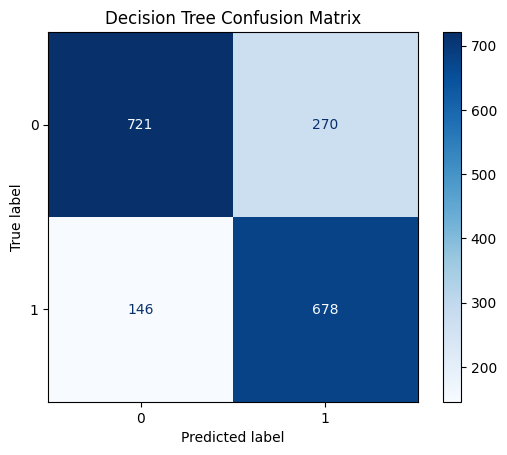

In [7]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [8]:
test_auprc = average_precision_score(y_test, y_test_prob)
print("Test AUPRC:", round(test_auprc, 4))

Test AUPRC: 0.761


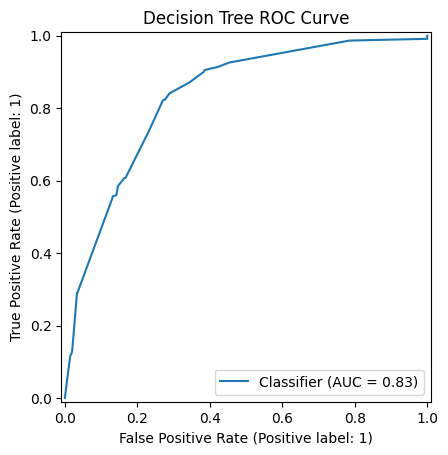

In [9]:
RocCurveDisplay.from_predictions(y_test, y_test_prob)
plt.title("Decision Tree ROC Curve")
plt.show()

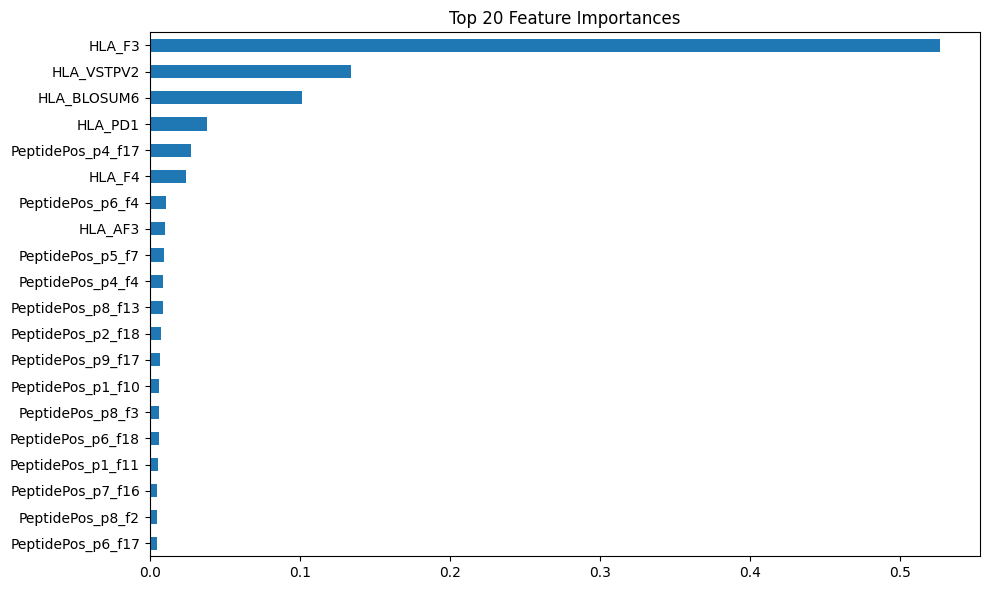

In [32]:
importances = cart.feature_importances()
importances.head(20).plot(kind="barh", figsize=(10, 6))
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

# Hyperparameter tuning (cross-validation)

In [36]:
def cross_val_score_cart(X, y, groups, model_params, k=5):
    gkf = GroupKFold(n_splits=k)
    
    scores = []
    
    for train_idx, val_idx in gkf.split(X, y, groups):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        
        model = CARTClassifier(**model_params)
        model.fit(X_tr, y_tr, feature_names=feature_names)
        
        scores.append(model.score(X_val, y_val))
    
    return np.mean(scores)

In [38]:
from itertools import product
from sklearn.model_selection import GroupKFold
import numpy as np
import pandas as pd

# ---------------------------
# 1. DEFINE GROUPS (IMPORTANT FIX)
# ---------------------------
train_groups = peptides.iloc[train_idx]

# ---------------------------
# 2. SANITY CHECK (HIGHLY RECOMMENDED)
# ---------------------------
assert len(X_train) == len(y_train) == len(train_groups), "Mismatch in train data and groups!"
print("Sanity check passed: X_train, y_train, train_groups aligned")

# Optional: check leakage (same peptide repeated across folds is OK here, but helps debugging)
print(f"Unique peptides in training set: {len(np.unique(train_groups))}")

# ---------------------------
# 3. CROSS-VALIDATION FUNCTION (GroupKFold-safe)
# ---------------------------
def cross_val_score_cart(X, y, groups, model_params, k=5):
    gkf = GroupKFold(n_splits=k)
    
    scores = []
    
    for train_idx_cv, val_idx_cv in gkf.split(X, y, groups):
        X_tr, X_val = X.iloc[train_idx_cv], X.iloc[val_idx_cv]
        y_tr, y_val = y[train_idx_cv], y[val_idx_cv]
        
        model = CARTClassifier(**model_params)
        model.fit(X_tr, y_tr, feature_names=feature_names)
        
        scores.append(model.score(X_val, y_val))
    
    return np.mean(scores)

# ---------------------------
# 4. GRID SEARCH
# ---------------------------
max_depths = [3, 5, 6, 8, 10]
min_samples_splits = [2, 5, 10]
min_samples_leafs = [1, 2, 5, 10]

results = []

for depth, split, leaf in product(max_depths, min_samples_splits, min_samples_leafs):
    
    params = {
        "max_depth": depth,
        "min_samples_split": split,
        "min_samples_leaf": leaf
    }
    
    cv_score = cross_val_score_cart(
        X_train,
        y_train,
        train_groups,
        params,
        k=5
    )
    
    results.append({
        "max_depth": depth,
        "min_samples_split": split,
        "min_samples_leaf": leaf,
        "cv_score": cv_score
    })
    
    print(f"depth={depth} split={split} leaf={leaf} | CV={cv_score:.4f}")

# ---------------------------
# 5. BEST MODEL
# ---------------------------
results_df = pd.DataFrame(results).sort_values("cv_score", ascending=False)

best = results_df.iloc[0]

print("\nBest config:")
print(best)

Sanity check passed: X_train, y_train, train_groups aligned
Unique peptides in training set: 5363
depth=3 split=2 leaf=1 | CV=0.7552
depth=3 split=2 leaf=2 | CV=0.7552
depth=3 split=2 leaf=5 | CV=0.7552
depth=3 split=2 leaf=10 | CV=0.7545
depth=3 split=5 leaf=1 | CV=0.7552
depth=3 split=5 leaf=2 | CV=0.7552
depth=3 split=5 leaf=5 | CV=0.7552
depth=3 split=5 leaf=10 | CV=0.7545
depth=3 split=10 leaf=1 | CV=0.7552
depth=3 split=10 leaf=2 | CV=0.7552
depth=3 split=10 leaf=5 | CV=0.7552
depth=3 split=10 leaf=10 | CV=0.7545
depth=5 split=2 leaf=1 | CV=0.7635
depth=5 split=2 leaf=2 | CV=0.7638
depth=5 split=2 leaf=5 | CV=0.7643
depth=5 split=2 leaf=10 | CV=0.7649
depth=5 split=5 leaf=1 | CV=0.7633
depth=5 split=5 leaf=2 | CV=0.7638
depth=5 split=5 leaf=5 | CV=0.7643
depth=5 split=5 leaf=10 | CV=0.7649
depth=5 split=10 leaf=1 | CV=0.7633
depth=5 split=10 leaf=2 | CV=0.7636
depth=5 split=10 leaf=5 | CV=0.7643
depth=5 split=10 leaf=10 | CV=0.7649
depth=6 split=2 leaf=1 | CV=0.7633
depth=6 split

In [39]:
results_df = pd.DataFrame(results).sort_values("cv_score", ascending=False)

best = results_df.iloc[0]

print("\nBest config:")
print(best)


Best config:
max_depth             5.000000
min_samples_split    10.000000
min_samples_leaf     10.000000
cv_score              0.764855
Name: 23, dtype: float64


# refit with best config


Best CV config used:
max_depth             5.000000
min_samples_split    10.000000
min_samples_leaf     10.000000
cv_score              0.764855
Name: 23, dtype: float64

-- Validation --
Accuracy : 0.7586
ROC-AUC  : 0.8190
AUPRC    : 0.7500

-- Test --
Accuracy : 0.7796
ROC-AUC  : 0.8388
AUPRC    : 0.7667
              precision    recall  f1-score   support

           0       0.85      0.73      0.78       991
           1       0.72      0.84      0.78       824

    accuracy                           0.78      1815
   macro avg       0.78      0.79      0.78      1815
weighted avg       0.79      0.78      0.78      1815



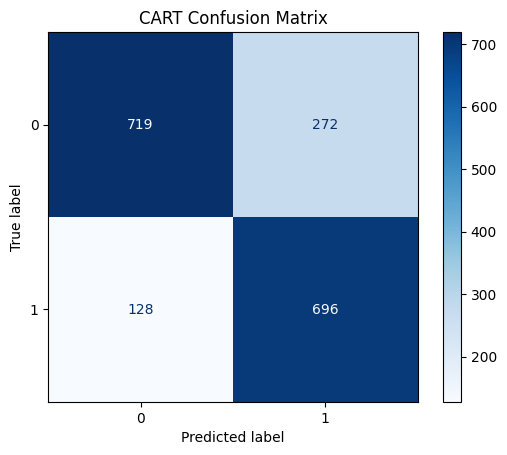

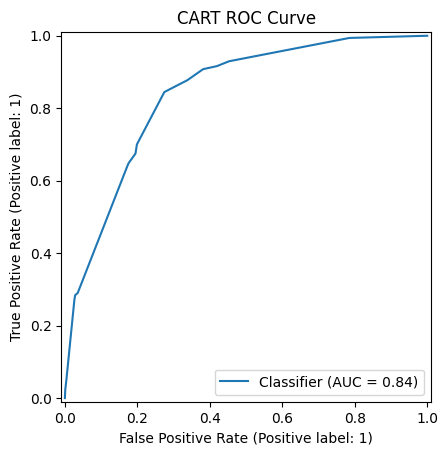

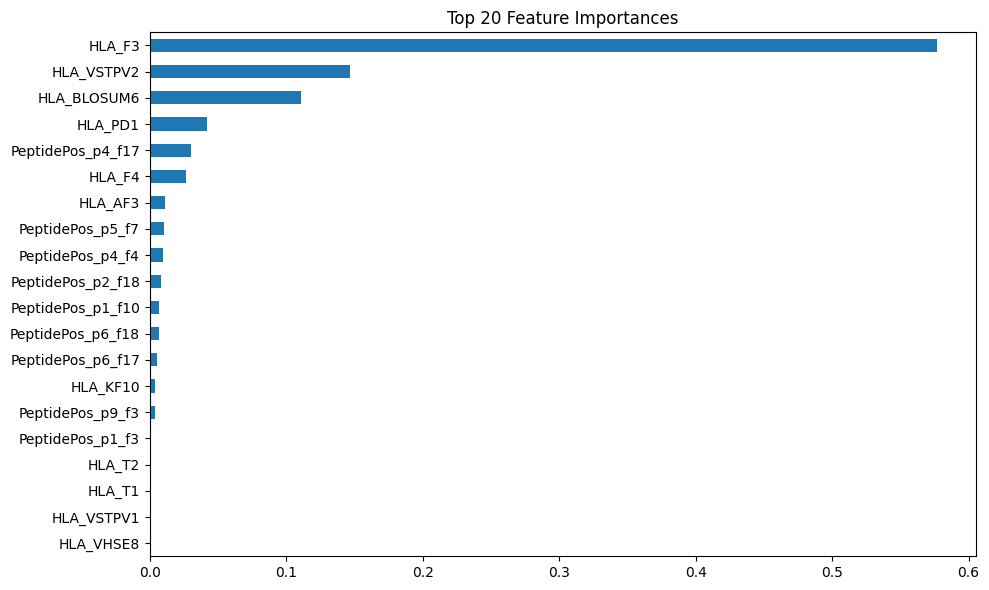

In [41]:
# ---------------------------
# Refit best model from CV
# ---------------------------
best = results_df.iloc[0]

final_cart = CARTClassifier(
    max_depth=int(best["max_depth"]),
    min_samples_split=int(best["min_samples_split"]),
    min_samples_leaf=int(best["min_samples_leaf"])
)

final_cart.fit(X_train, y_train, feature_names=feature_names)

print("\nBest CV config used:")
print(best)

# ---------------------------
# Validation evaluation
# ---------------------------
y_val_pred = final_cart.predict(X_val)
y_val_prob = final_cart.predict_proba(X_val)[:, 1]

print("\n-- Validation --")
print(f"Accuracy : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, y_val_prob):.4f}")
print(f"AUPRC    : {average_precision_score(y_val, y_val_prob):.4f}")

# ---------------------------
# Test evaluation (final report)
# ---------------------------
y_test_pred = final_cart.predict(X_test)
y_test_prob = final_cart.predict_proba(X_test)[:, 1]

print("\n-- Test --")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"AUPRC    : {average_precision_score(y_test, y_test_prob):.4f}")
print(classification_report(y_test, y_test_pred))

# ---------------------------
# Confusion Matrix
# ---------------------------
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("CART Confusion Matrix")
plt.show()

# ---------------------------
# ROC Curve
# ---------------------------
RocCurveDisplay.from_predictions(y_test, y_test_prob)
plt.title("CART ROC Curve")
plt.show()

# ---------------------------
# Feature Importance
# ---------------------------
importances = final_cart.feature_importances()

importances.head(20).plot(kind="barh", figsize=(10, 6))
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()